# Alex Analysis

### Question

- What is the relationship between the origin of production of a film to the amount of money it grosses?


#### My Analysis will include
1. Descriptive Statistics
2. Inferential Statistics
3. Graphical Analysis
4. Comparative Analysis
5. Multivariate Analysis
6. Synthesis
7. Documentation
8. Reporting & Interpretation
9. Reflection


In [163]:
# Loading in neccessary packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from scipy.stats import chi2_contingency
import warnings
warnings.simplefilter(action='ignore')



In [120]:
# Read in CSV file to create DataFrame
movie_df = pd.read_csv('movies.csv')



# Creating a new DataFrame using the explode method to get all the movies with multiple production countries and cleaning for blank spaces
movie_expanded_df = movie_df.assign(productionCountries=movie_df['productionCountries'].str.split(',')).explode('productionCountries')
movie_expanded_df['productionCountries'] = movie_expanded_df['productionCountries'].str.strip().str.title()


# Getting all the countries means and standard deviation for Domestic and Foreign Gross Revenue
movie_expanded_df.groupby('productionCountries')[['domesticGross', 'foreignGross', 'worldwideGross']].agg(['mean','std'])




domesticGross                foreignGross  \
                                  mean           std          mean   
productionCountries                                                  
Algeria                   3.207000e+05           NaN  2.264300e+07   
Argentina                 4.005980e+06  6.066552e+06  3.106690e+07   
Australia                 4.462983e+07  4.468630e+07  5.380649e+07   
Austria                   5.755767e+06  6.517976e+06  2.746711e+07   
Bahamas                   5.353320e+07  3.339569e+07  3.145859e+07   
...                                ...           ...           ...   
Ukraine                   0.000000e+00  0.000000e+00  2.206056e+07   
United Arab Emirates      2.737870e+07  3.190732e+07  3.743386e+07   
United Kingdom            4.466511e+07  7.653040e+07  8.140617e+07   
United States Of America  6.322070e+07  8.380800e+07  8.342607e+07   
Vietnam                   1.667350e+06  4.576196e+06  1.483460e+07   

                                       worldwideGross                
                                   std           mean           std  
productionCountries                                                  
Algeria                            NaN   2.296370e+07           NaN  
Argentina                 1.848397e+07   3.507288e+07  2.070323e+07  
Australia                 6.194262e+07   9.843633e+07  1.008609e+08  
Austria                   3.533941e+07   3.322287e+07  3.902563e+07  
Bahamas                   1.908282e+07   8.499179e+07  5.247851e+07  
...                                ...            ...           ...  
Ukraine                   5.777912e+06   2.206056e+07  5.777912e+06  
United Arab Emirates      5.165421e+07   6.481256e+07  6.432160e+07  
United Kingdom            1.561182e+08   1.260716e+08  2.272901e+08  
United States Of America  1.468841e+08   1.466471e+08  2.234270e+08  
Vietnam                   6.305768e+06   1.650195e+07  7.770450e+06  

[75 rows x 6 columns]

In [ ]:
# Getting the top 10 countries with the most amount of films produced
movie_expanded_df.groupby('productionCountries').size().nlargest(10).sort_values(ascending=False)


productionCountries
United States Of America    4556
United Kingdom               878
France                       631
Japan                        540
China                        535
Germany                      474
South Korea                  361
Canada                       352
Hong Kong                    262
India                        248
dtype: int64

In [199]:
# Creating a DataFrame with the top 10 countries with the most films produced

# Count number of movies per country
country_counts = movie_expanded_df.groupby('productionCountries').size()

# Getting the top 10 countries (by movie count)
top10_countries = country_counts.nlargest(10).index

# Filtering the original DataFrame to include only from countries in the top 10
top10_df = movie_expanded_df[movie_expanded_df['productionCountries'].isin(top10_countries)]

# Creating Log Transformation for better visuals
top10_df['log_worldwideGross'] = np.log(top10_df['worldwideGross'] + 1)



# Multiple Linear Regression

In [200]:
# Linear regression of where a film is produced to worldwide gross(revenue)


# This automatically handles categorical variables.
model = smf.ols('worldwideGross ~ C(productionCountries)', data=top10_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         worldwideGross   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     37.81
Date:                Tue, 18 Mar 2025   Prob (F-statistic):           1.52e-66
Time:                        17:44:49   Log-Likelihood:            -1.8088e+05
No. Observations:                8837   AIC:                         3.618e+05
Df Residuals:                    8827   BIC:                         3.618e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

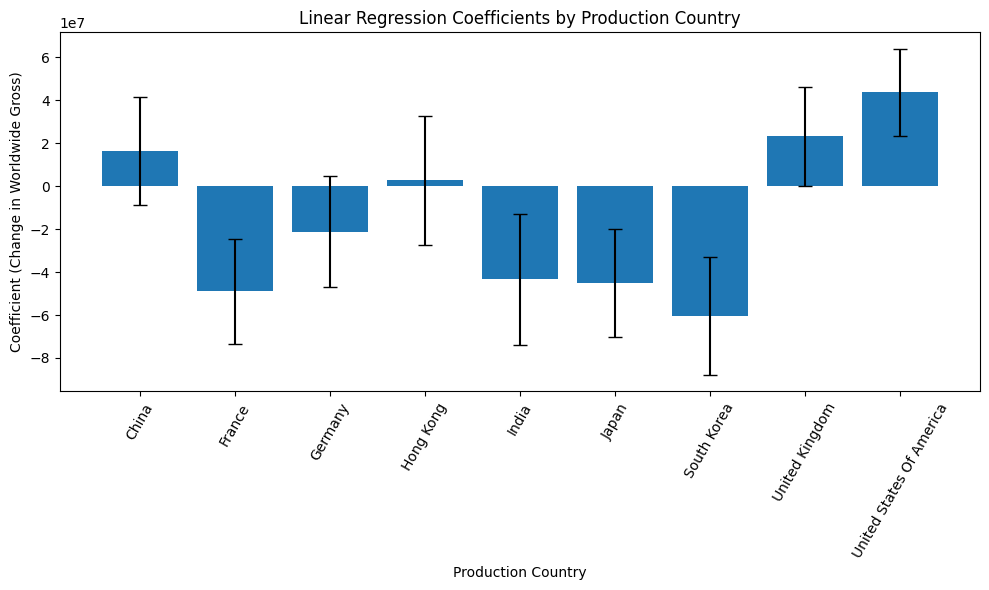

In [196]:
# Visual Representation of Linear Regression

# Get coefficients (excluding intercept) and confidence intervals
coefs = model.params.drop('Intercept')
conf_int = model.conf_int().drop('Intercept')

# Remove the prefix/suffix from the index
coefs.index = coefs.index.str.replace(r'C\(productionCountries\)\[T\.', '', regex=True)
coefs.index = coefs.index.str.replace(r'\]', '', regex=True)

conf_int.index = conf_int.index.str.replace(r'C\(productionCountries\)\[T\.', '', regex=True)
conf_int.index = conf_int.index.str.replace(r'\]', '', regex=True)

# Calculate error bars
lower_errors = coefs - conf_int[0]
upper_errors = conf_int[1] - coefs

# Plot
plt.figure(figsize=(10,6))
plt.bar(coefs.index, coefs.values, yerr=[lower_errors, upper_errors], capsize=5)
plt.xticks(rotation=60)
plt.xlabel('Production Country')
plt.ylabel('Coefficient (Change in Worldwide Gross)')
plt.title('Linear Regression Coefficients by Production Country')
plt.tight_layout()
plt.show()

# Explanation of Linear Regression
- The purpose is to measure how much the film's gross changes on average for films from different counties based on the baseline(Canada)
- The variable I used for this regression was 'productionCounties' and convert it to be continuous 
- This shows the postive and negative coefficents on which are higher or lower gross earnings

# Anova Testing

In [ ]:
# Fit a model using ordinary least squares.

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                              sum_sq      df          F        PR(>F)
C(productionCountries)  1.198030e+19     9.0  37.814775  1.518385e-66
Residual                3.107255e+20  8827.0        NaN           NaN


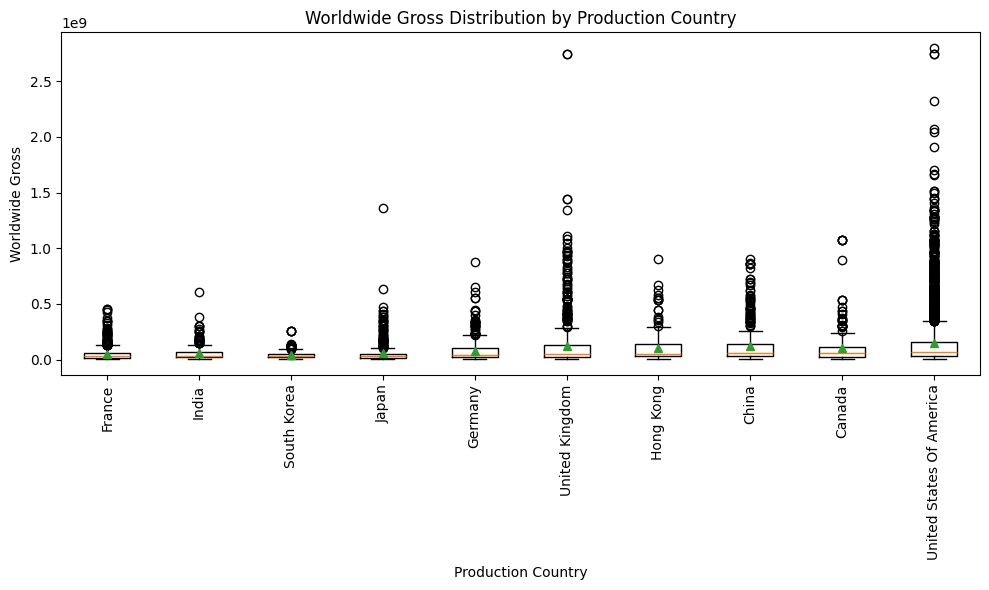

In [ ]:
# Visual representation of ANOVA test

# Sort countries by median worldwideGross for clarity
countries_sorted = top10_df.groupby('productionCountries')['worldwideGross'].median().sort_values().index

# Preparing data to create a list of worldwideGross values per country
data_to_plot = [movie_expanded_df[movie_expanded_df['productionCountries'] == country]['worldwideGross'] for country in countries_sorted]

plt.figure(figsize=(10,6))
plt.boxplot(data_to_plot, labels=countries_sorted, showmeans=True)
plt.xticks(rotation=90)
plt.xlabel('Production Country')
plt.ylabel('Worldwide Gross')
plt.title('Worldwide Gross Distribution by Production Country')
plt.tight_layout()
plt.show()

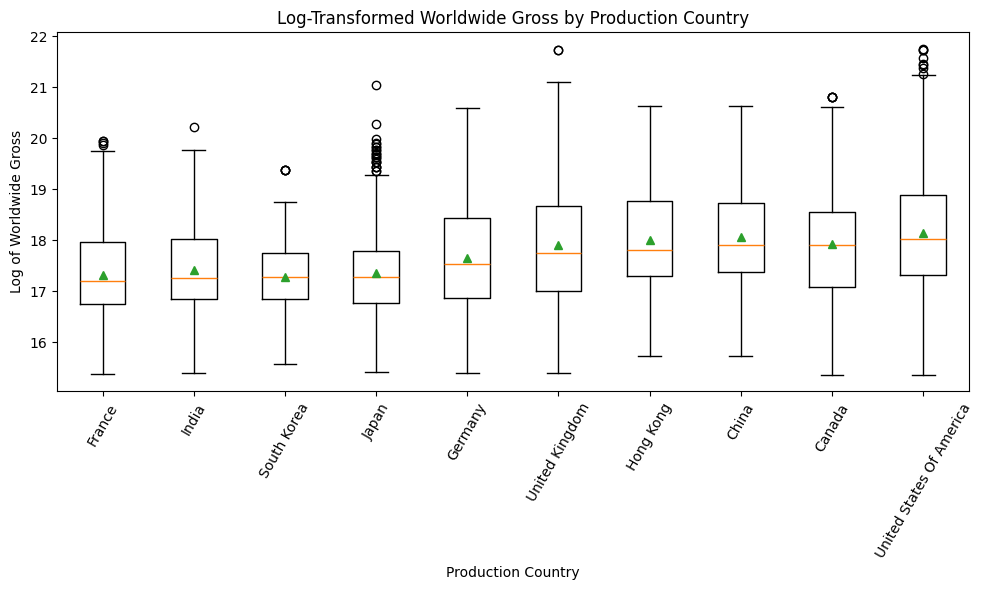

In [183]:

# Creating Log Transformation for better visuals
top10_df['log_worldwideGross'] = np.log(top10_df['worldwideGross'] + 1)

# Visual representation of ANOVA test (Updated)
countries_sorted = (
    top10_df.groupby('productionCountries')['log_worldwideGross']
    .median()
    .sort_values()
    .index
)
data_to_plot = [
    top10_df[top10_df['productionCountries'] == country]['log_worldwideGross']
    for country in countries_sorted
]

plt.figure(figsize=(10,6))
plt.boxplot(data_to_plot, labels=countries_sorted, showmeans=True)
plt.xticks(rotation=60)
plt.xlabel('Production Country')
plt.ylabel('Log of Worldwide Gross')
plt.title('Log-Transformed Worldwide Gross by Production Country')
plt.tight_layout()
plt.show()

# Explanation of ANOVA
- The purpose is to see if there are statistically significant differences in the mean gross across different production countries.
- The variable I used for this ANOVA test was 'productionCounties'.
- The boxplots help us see the distribution and spread of gross for each country.


# Chi-Squre Test


<Figure size 1000x600 with 0 Axes>

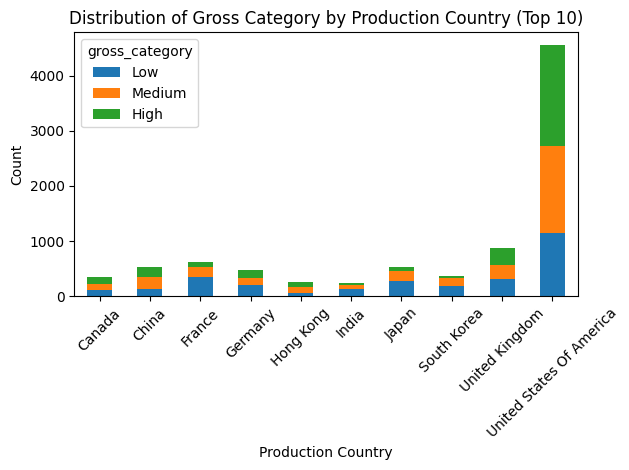

In [ ]:
# Bin worldwideGross into 3 categories (Low, Medium, High)
top10_df['gross_category'] = pd.qcut(top10_df['worldwideGross'], q=3, labels=['Low', 'Medium', 'High'])

# Create a contingency table that counts the gross_category for each production country
contingency_table = pd.crosstab(top10_df['productionCountries'], top10_df['gross_category'])



plt.figure(figsize=(10,6))
contingency_table.plot(kind='bar', stacked=True)
plt.xlabel('Production Country')
plt.ylabel('Count')
plt.title('Distribution of Gross Category by Production Country (Top 10)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [189]:
# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print results
print("Chi-square statistic:", chi2)
print("P-value:", p)


Chi-square statistic: 676.5796353054453
P-value: 5.26928735384469e-132


In [179]:
# Assuming 'gross_category' has already been created in your DataFrame
crosstab_country_gross = pd.crosstab(top10_df['productionCountries'],
                                     top10_df['gross_category'])
print(crosstab_country_gross)

gross_category             Low  Medium  High
productionCountries                         
Canada                     114     105   133
China                      130     215   190
France                     358     168   105
Germany                    211     130   133
Hong Kong                   66     103    93
India                      135      67    46
Japan                      285     182    73
South Korea                192     135    34
United Kingdom             314     253   311
United States Of America  1141    1587  1828


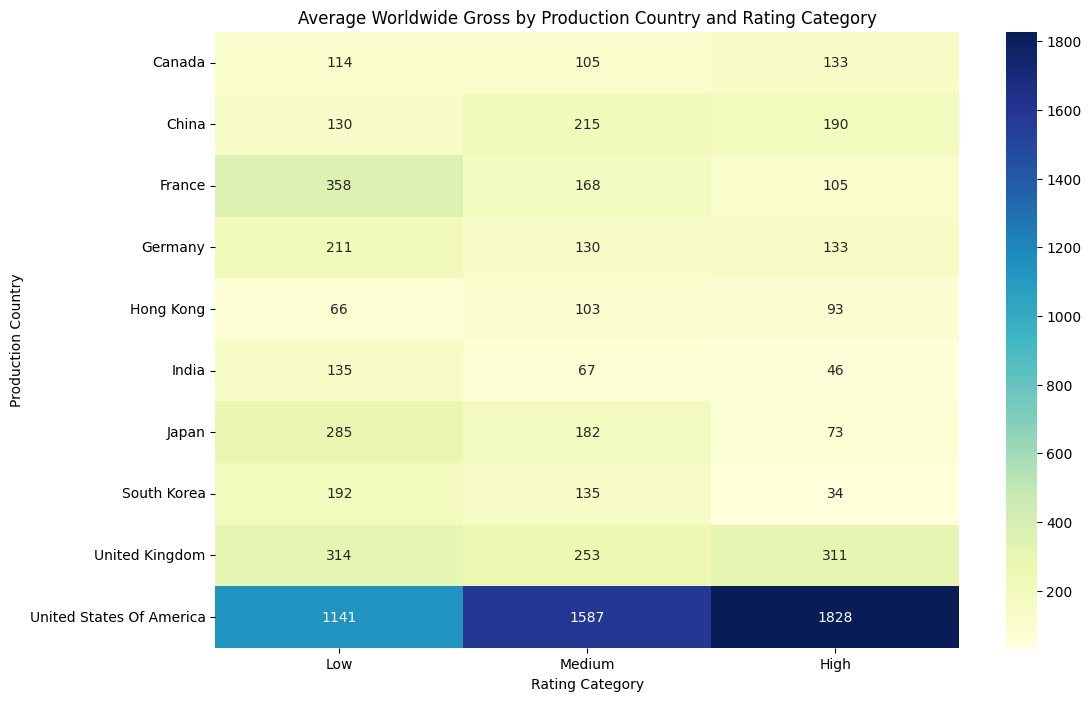

In [180]:
plt.figure(figsize=(12,8))
sns.heatmap(crosstab_country_gross, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Average Worldwide Gross by Production Country and Rating Category')
plt.ylabel('Production Country')
plt.xlabel('Rating Category')
plt.show()

# Explanation of Chi-Square Test
- The purpose was to find if there were any statistically significant differences in the mean gross across different production countries.
- The variables used was were 'productionCountries' and 'gross_category'
- The distribution of gross categories differs by production country. 
- The stacked bar chart can shows the differences between countries.



# Reflection
#### Challenges:
- As a team we intergrated a new data source to our project. With new data introduced there was some cleaning needing to be done to get accurate data. 
- While calculating descriptive statistics (mean and standard deviation) by country, I noticed inconsistencies due to differing group sizes. To verify this, I manually found Argentina’s mean which confirmed the issue. Stripping whitespace (strip()) from the ‘productionCounties’ column resolved the discrepancies and ensured consistent results.
- A possible limitation is the data skew, with most films produced in the USA (4556 entries) compared to the seccond most films produced with United Kingdom's 878.